Submit your answers to gradescope before or at the latest at 12:50pm.

In [1]:
using Plots

In [2]:
using FFTW

In [3]:
using FastGaussQuadrature

In [4]:
using JuMP
using GLPK

# Question 1

Consider a composite product with three components.

The product fails if the first component fails or if both
the second and third component fail.

The life span of the $i$th component $c_i$ is 
normally distributed with averages $\mu$ 
and standard deviations $\sigma$ listed in hours below:

$$
   \begin{array}{c|c|c}
        & \mu & \sigma \\ \hline
   c_1 &  500 & 100 \\
   c_2 &  400 & 150 \\
   c_3 &  300 & 200
   \end{array}
$$

Define a Monte Carlo simulation to estimate the average life span
of this composite product.

Run at least 10,000 iterations in the simulation.

## answer to question 1

We adjust the ``mtbf`` function from the lecture.

In [5]:
function mtbf(means::Vector{Float64}, deviations::Vector{Float64}, N::Int,
             verbose::Bool=false)
   (m1, m2) = (0, 0)                       # first and second moment
   sample = [0.0 for j=1:length(means)]    # work space for each sample
   for i=1:N                               # run N simulations
       for j=1:length(means)               # randn() has mean 0, sigma 1
           sample[j] = means[j] + deviations[j]*randn()
       end
       if verbose                          # for debugging purposes ...
           println("sample : ", sample)
       end
       lifespan = min(sample[1], max(sample[2], sample[3]))
       m1 = m1 + lifespan/N                # update the average
       m2 = m2 + lifespan*lifespan/N       # update second moment
   end
   return (m1, sqrt(m2 - m1*m1))           # mean and deviation
end

mtbf (generic function with 2 methods)

In [6]:
(mu, sigma) = mtbf([500.0, 400.0, 300.0], [100.0, 150.0, 200.0], 100000)
println("The expected life span is : ", mu)
println("The standard deviation is : ", sigma)

The expected life span is : 408.5724635789825
The standard deviation is : 103.83450015884672


# Question 2

Let $f(t) = 5 \sin(4 \cdot 2 \pi t) + 2 \sin(8 \cdot 2 \pi t)$
represent a signal, for $t \in [0,4]$.

1. Use the FFT to compute the spectrum.
    
   Explain how from the spectrum you can
   recognize the two components of $f$.

2. From the spectrum, remove the second component of $f$.
    
3. Compute the inverse FFT of the spectrum
   with the second component removed.
   
   Make a plot of the new signal, for $t \in [0,4]$.
   
   Explain the differences with the original signal.

## answer to question 2

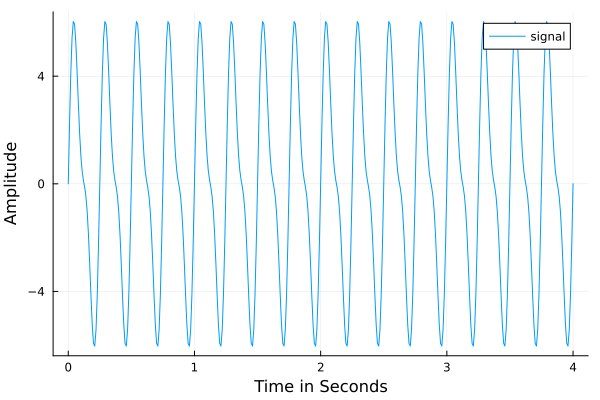

In [7]:
dt = 0.01
t = 0:dt:4
y = 5*sin.(4*2*pi*t) + 2*sin.(8*2*pi*t)
plot(t, y, yticks=-24:4:24, label="signal",
     xlabel="Time in Seconds", ylabel="Amplitude")

The plot has two peaks. One at a frequency of 4 hertz with an amplitude of 5 and one at a frequency of 8 hertz with an amplitude of 2


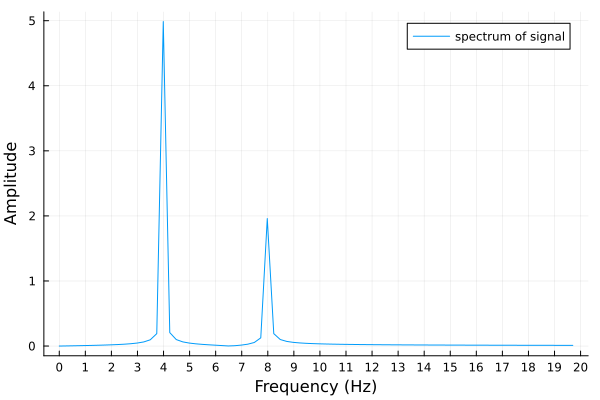

In [8]:
F = fft(y)
n = length(y)/2
amps = abs.(F)/n
freq = [0:79]/(2*n*dt)
println("The plot has two peaks. One at a frequency of 4 hertz with an amplitude of 5 and one at a frequency of 8 hertz with an amplitude of 2")
plot(freq, amps[1:80], xticks=0:1:20, label="spectrum of signal",
    ylabel="Amplitude", xlabel="Frequency (Hz)")

We look where the high peaks are in the spectrum.

In [9]:
findall(x-> abs(x) > 4.5, amps)

2-element Vector{Int64}:
  17
 386

In [10]:
findall(x-> 3. > abs(x) > 1.5, amps)

2-element Vector{Int64}:
  33
 370

We remove the second component.

In [11]:
filtamps = amps
filtamps[30:36] = zeros(7)
filtamps[367:373] = zeros(7)

7-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

We plot to verify that the second, smaller peak is gone.

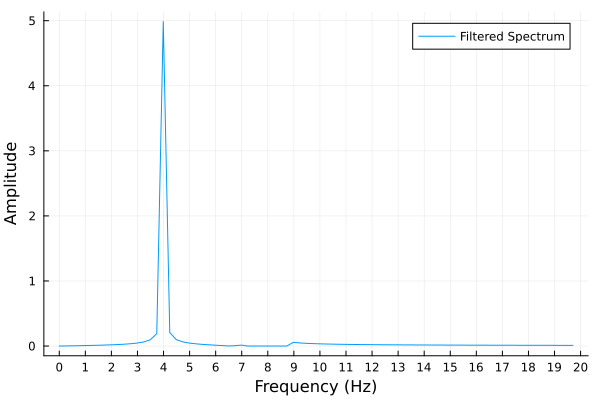

In [12]:
n = length(filtamps)/2
amps2 = abs.(filtamps)
freq2 = [0:79]/(2*n*dt)
plot(freq2, amps2[1:80], xticks=0:1:20, label="Filtered Spectrum",
     ylabel="Amplitude", xlabel="Frequency (Hz)")

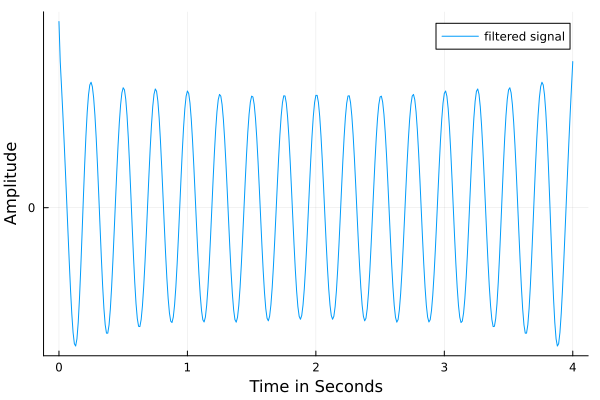

In [13]:
yfiltsignal = ifft(filtamps)
plot(t, real(yfiltsignal), yticks=-7:1:7, label="filtered signal",
     xlabel="Time in Seconds", ylabel="Amplitude")

In the filtered signal we see that only one frequency remains.

# Question 3

Let $f(t) = (\cos(2\pi t))^4$.

Compute a least squares approximation for $f$
using a Fourier basis of sines and cosines.

How many basis functions are needed for the largest error of
the least squares approximation to be less than $10^5$ over $[-1,+1]$?

## answer to question 3

In [14]:
f(t) = (cos(2*pi*t))^4

f (generic function with 1 method)

In [15]:
nodes, weights = gausslegendre(32)
rule(f) = sum([weights[k]*f(nodes[k]) for k=1:length(weights)])

rule (generic function with 1 method)

In [16]:
"""
    function innerproduct(f::Function, g::Function)

returns the value of the inner product of the functions f and g,
by the integral of f and g over [-1,+1].
"""
function innerproduct(f::Function, g::Function)
    fun(x) = f(x)*g(x)
    return rule(fun)
end

innerproduct

In [17]:
"""
    function basis(n::Int64)

returns an array of functions with the first 2*n basis functions.
"""
function basis(n::Int64)
    one = [(t) -> 1]
    sines = [(t) -> sin(k*pi*t) for k=1:n]
    cosines = [(t) -> cos(k*pi*t) for k=1:n]
    result = [one; sines; cosines]
    return result
end

basis

In [18]:
"""
    function coefficients(f::Function,b::Array{Function,1})

returns the inner products of f with the basis functions in b.
"""
function coefficients(f::Function,b::Array{Function,1})
    dim = length(b)
    result = zeros(dim)
    for i=1:dim
        result[i] = innerproduct(f,b[i])
    end
    return result
end

coefficients

In [19]:
"""
    function approximation(c::Array{Float64,1},b::Array{Function,1})

Given in c are the coefficients of the Chebyshev approximation
with the basis functions in f.
Returns the approximation as a function.
"""
function approximation(c::Array{Float64,1},b::Array{Function,1})
    first(x) = c[1]*b[1](x)/2
    rest(x) = sum([c[k]*b[k](x) for k=2:length(c)])
    result(x) = first(x) + rest(x)
    return result
end

approximation

We start with 11 basis functions, but we need 17 basis functions.

In [20]:
bN = basis(8)
cN = coefficients(f, bN)
aN = approximation(cN,bN)

(::var"#result#approximation##4"{var"#rest#approximation##1"{Vector{Float64}, Vector{Function}}, var"#first#approximation##0"{Vector{Float64}, Vector{Function}}}) (generic function with 1 method)

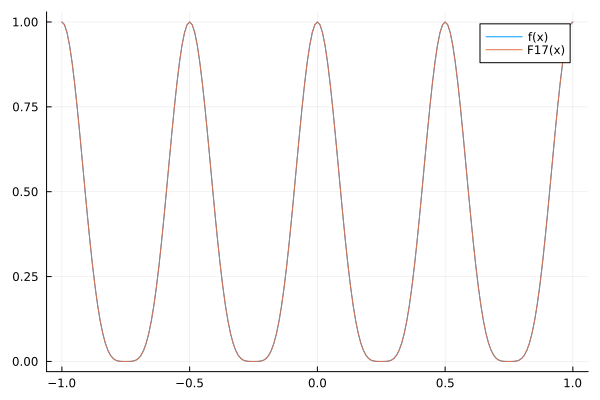

In [21]:
xr = -1.0:0.01:1.0
fx = [f(t) for t in xr]
px = [aN(t) for t in xr]
plot(xr,fx,label="f(x)",legend=:topright)
plot!(xr,px,label="F17(x)")

We see that the approximation agrees with the given function.

# Question 4

A sales manager needs to organize trips for three representatives
$R_1$, $R_2$, and $R_3$
to visit three different locations $L_1$, $L_2$, and $L_3$.
Each representative can travel to each location, but their travel costs
are different for each location, as listed in the table below:

$$
  \begin{array}{c||r|r|r}
  & L_1 & L_2 & L_3 \\ \hline
  R_1  &    \$730 & \$728 &   \$558 \\
  R_2  &   \$984  & \$791 & \$1,033 \\
  R_3  & \$1,046  & \$670 &   \$518 \\
  \end{array}
$$

The goal is to assign to each representative one location
so that all locations are visited in the most economical manner.

Set up a linear programming  model for this problem.

## answer to question 4

We use JuMP to model this problem.

Let $ x_{ij} \in \{0,1\}$ be a 0/1 variable: 1 if representative i is assigned to visit location j, and 0 otherwise. 

Let $c_{ij}$ be the cost for representative $i$ to visit location $j$.

Our objective function is
   $$ \min \sum_{i=1}^3 \sum_{j=1}^3 c_{ij} x_{ij}$$
with constraints that all locations must be visited, each location by exactly one representative:
   $$ x_{11} + x_{12} + x_{13} = 1, x_{21} + x_{22} + x_{23} = 1, x_{31} + x_{32} + x_{33} = 1$$
   $$ x_{11} + x_{21} + x_{31} = 1, x_{12} + x_{22} + x_{32} = 1, x_{13} + x_{23} + x_{33} = 1$$

In [22]:
c = [730 728 558;
     984 791 1033;
    1046 670 518]

3×3 Matrix{Int64}:
  730  728   558
  984  791  1033
 1046  670   518

In [23]:
model = Model(GLPK.Optimizer)

A JuMP Model
├ solver: GLPK
├ objective_sense: FEASIBILITY_SENSE
├ num_variables: 0
├ num_constraints: 0
└ Names registered in the model: none

In [24]:
@variable(model, x[1:3, 1:3], Bin)

3×3 Matrix{VariableRef}:
 x[1,1]  x[1,2]  x[1,3]
 x[2,1]  x[2,2]  x[2,3]
 x[3,1]  x[3,2]  x[3,3]

We minimize the total cost for all travels.

In [25]:
@objective(model, Min, sum(c[i,j] * x[i,j] for i=1:3, j=1:3))

730 x[1,1] + 728 x[1,2] + 558 x[1,3] + 984 x[2,1] + 791 x[2,2] + 1033 x[2,3] + 1046 x[3,1] + 670 x[3,2] + 518 x[3,3]

Each representative visits one location.

In [26]:
@constraint(model, representative[i=1:3], sum(x[i,j] for j in 1:3) == 1)

3-element Vector{ConstraintRef{Model, MathOptInterface.ConstraintIndex{MathOptInterface.ScalarAffineFunction{Float64}, MathOptInterface.EqualTo{Float64}}, ScalarShape}}:
 representative[1] : x[1,1] + x[1,2] + x[1,3] == 1
 representative[2] : x[2,1] + x[2,2] + x[2,3] == 1
 representative[3] : x[3,1] + x[3,2] + x[3,3] == 1

Each location is visited by one representative.

In [27]:
@constraint(model, loation[j=1:3], sum(x[i,j] for i in 1:3) == 1)

3-element Vector{ConstraintRef{Model, MathOptInterface.ConstraintIndex{MathOptInterface.ScalarAffineFunction{Float64}, MathOptInterface.EqualTo{Float64}}, ScalarShape}}:
 loation[1] : x[1,1] + x[2,1] + x[3,1] == 1
 loation[2] : x[1,2] + x[2,2] + x[3,2] == 1
 loation[3] : x[1,3] + x[2,3] + x[3,3] == 1

In [28]:
print(model)

In [29]:
optimize!(model)
solution_summary(model)

solution_summary(; result = 1, verbose = false)
├ solver_name          : GLPK
├ Termination
│ ├ termination_status : OPTIMAL
│ ├ result_count       : 1
│ ├ raw_status         : Solution is optimal
│ └ objective_bound    : 2.03900e+03
├ Solution (result = 1)
│ ├ primal_status        : FEASIBLE_POINT
│ ├ dual_status          : NO_SOLUTION
│ ├ objective_value      : 2.03900e+03
│ └ relative_gap         : 0.00000e+00
└ Work counters
  └ solve_time (sec)   : 3.99995e-03

In [30]:
print("minimum total cost : ", objective_value(model))

minimum total cost : 2039.0

In [31]:
println("assignments :")
for i in 1:3
    for j in 1:3
        if value(x[i,j]) == 1
            println("  Representative ", i, " visits location ", j)
        end
    end
end

assignments :
  Representative 1 visits location 1
  Representative 2 visits location 2
  Representative 3 visits location 3


# Question 5

Describe in one paragraph what you learned 
from *another* project presentation.